<a href="https://colab.research.google.com/github/fatahrahimi330/XST-Deepfake-Detection/blob/master/new_version/1_new_version.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Full Proper Video Model Pipeline

## 1. Imports

In [ ]:
import os
import random
import zipfile
import numpy as np
import matplotlib.pyplot as plt

from PIL import Image
from tqdm.auto import tqdm
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    ConfusionMatrixDisplay,
    accuracy_score,
    f1_score
)

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import timm

## 2. Set seed

In [ ]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)

## 3. Mount drive and unzip dataset

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

# zip_path = "/content/drive/MyDrive/processed_ffpp.zip"
# extract_path = "/content/processed_ffpp"

# os.makedirs(extract_path, exist_ok=True)

# with zipfile.ZipFile(zip_path, 'r') as zip_ref:
#     zip_ref.extractall(extract_path)

# print("Extraction complete!")
# print(os.listdir(extract_path))

Mounted at /content/drive


## 4. Set dataset root

In [ ]:
data_root = "/content/drive/MyDrive/XST-Deepfake-Detection/processed_ffpp"
print(os.listdir(data_root))

['.DS_Store', 'val', 'train', 'test']


## 5. Transforms

In [ ]:
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2,
        hue=0.05
    ),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

val_test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

## 6. Video sequence dataset

In [ ]:
class VideoFrameDataset(Dataset):
    """
    One sample = one video folder containing multiple frame images.
    Returns:
        frames_tensor: shape (T, C, H, W)
        label: 0 for fake, 1 for real
    """

    IMG_EXTS = (".jpg", ".jpeg", ".png")

    def __init__(self, root_dir, transform=None, num_frames=8, mode="uniform"):
        self.root_dir = root_dir
        self.transform = transform
        self.num_frames = num_frames
        self.mode = mode  # "uniform" or "random"

        self.classes = ["fake", "real"]
        self.class_to_idx = {"fake": 0, "real": 1}
        self.samples = []

        for class_name in self.classes:
            class_dir = os.path.join(root_dir, class_name)
            if not os.path.isdir(class_dir):
                continue

            for video_name in sorted(os.listdir(class_dir)):
                video_dir = os.path.join(class_dir, video_name)
                if not os.path.isdir(video_dir):
                    continue

                frame_files = sorted([
                    os.path.join(video_dir, f)
                    for f in os.listdir(video_dir)
                    if f.lower().endswith(self.IMG_EXTS)
                ])

                if len(frame_files) == 0:
                    continue

                self.samples.append((frame_files, self.class_to_idx[class_name], video_dir))

        print(f"[{root_dir}] Found {len(self.samples)} videos.")

    def __len__(self):
        return len(self.samples)

    def _sample_indices(self, n_frames):
        if n_frames >= self.num_frames:
            if self.mode == "random":
                indices = sorted(random.sample(range(n_frames), self.num_frames))
            else:
                indices = np.linspace(0, n_frames - 1, self.num_frames, dtype=int).tolist()
        else:
            # Repeat frames if video has fewer than num_frames
            indices = np.linspace(0, n_frames - 1, self.num_frames, dtype=int).tolist()

        return indices

    def __getitem__(self, idx):
        frame_files, label, video_dir = self.samples[idx]
        indices = self._sample_indices(len(frame_files))

        frames = []
        for i in indices:
            img_path = frame_files[i]
            img = Image.open(img_path).convert("RGB")

            if self.transform is not None:
                img = self.transform(img)

            frames.append(img)

        frames = torch.stack(frames, dim=0)  # (T, C, H, W)
        return frames, torch.tensor(label, dtype=torch.float32)

## 7. Create datasets and loaders

In [ ]:
NUM_FRAMES = 8
BATCH_SIZE = 4  # lower than frame model because sequence model uses more memory

train_dataset = VideoFrameDataset(
    root_dir=os.path.join(data_root, "train"),
    transform=train_transform,
    num_frames=NUM_FRAMES,
    mode="uniform"
)

val_dataset = VideoFrameDataset(
    root_dir=os.path.join(data_root, "val"),
    transform=val_test_transform,
    num_frames=NUM_FRAMES,
    mode="uniform"
)

test_dataset = VideoFrameDataset(
    root_dir=os.path.join(data_root, "test"),
    transform=val_test_transform,
    num_frames=NUM_FRAMES,
    mode="uniform"
)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

[/content/drive/MyDrive/XST-Deepfake-Detection/processed_ffpp/train] Found 280 videos.
[/content/drive/MyDrive/XST-Deepfake-Detection/processed_ffpp/val] Found 60 videos.
[/content/drive/MyDrive/XST-Deepfake-Detection/processed_ffpp/test] Found 60 videos.


## 8. Check shapes

In [ ]:
videos, labels = next(iter(train_loader))
print("Video batch shape:", videos.shape)   # (B, T, C, H, W)
print("Labels shape:", labels.shape)

Video batch shape: torch.Size([4, 8, 3, 224, 224])
Labels shape: torch.Size([4])


## 9. Improved CNN + ViT + BiLSTM model

In [ ]:
class CNN_ViT_BiLSTM(nn.Module):
    def __init__(
        self,
        cnn_model='efficientnet_b0',
        vit_model='vit_base_patch16_224',
        proj_dim=256,
        lstm_hidden=256,
        lstm_layers=1,
        dropout=0.3,
        freeze_cnn=True,
        freeze_vit=True
    ):
        super().__init__()

        # CNN backbone
        self.cnn = timm.create_model(cnn_model, pretrained=True)
        self.cnn.reset_classifier(0)
        cnn_feature_dim = self.cnn.num_features

        # ViT backbone
        self.vit = timm.create_model(vit_model, pretrained=True)
        self.vit.reset_classifier(0)
        vit_feature_dim = self.vit.num_features

        if freeze_cnn:
            for p in self.cnn.parameters():
                p.requires_grad = False

        if freeze_vit:
            for p in self.vit.parameters():
                p.requires_grad = False

        # Projection layers
        self.cnn_proj = nn.Sequential(
            nn.Linear(cnn_feature_dim, proj_dim),
            nn.ReLU(),
            nn.Dropout(dropout)
        )

        self.vit_proj = nn.Sequential(
            nn.Linear(vit_feature_dim, proj_dim),
            nn.ReLU(),
            nn.Dropout(dropout)
        )

        self.fusion_norm = nn.LayerNorm(proj_dim * 2)

        # Temporal modeling
        self.lstm = nn.LSTM(
            input_size=proj_dim * 2,
            hidden_size=lstm_hidden,
            num_layers=lstm_layers,
            batch_first=True,
            bidirectional=True,
            dropout=0.0 if lstm_layers == 1 else dropout
        )

        # Classification head
        self.classifier = nn.Sequential(
            nn.Linear(lstm_hidden * 2, 128),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128, 1)
        )

    def forward(self, x):
        # x: (B, T, C, H, W)
        B, T, C, H, W = x.shape
        x = x.view(B * T, C, H, W)

        # CNN features
        cnn_raw = self.cnn.forward_features(x)
        cnn_feat = self.cnn.global_pool(cnn_raw).flatten(1)

        # ViT features
        vit_raw = self.vit.forward_features(x)
        vit_feat = vit_raw[:, 0]  # CLS token

        # Projection
        cnn_feat = self.cnn_proj(cnn_feat)
        vit_feat = self.vit_proj(vit_feat)

        # Fusion
        fused = torch.cat([cnn_feat, vit_feat], dim=1)
        fused = self.fusion_norm(fused)

        # Sequence reshape
        seq_feat = fused.view(B, T, -1)

        # BiLSTM
        lstm_out, _ = self.lstm(seq_feat)

        # Temporal mean pooling
        temporal_feat = lstm_out.mean(dim=1)

        # Classification
        out = self.classifier(temporal_feat)
        return out

## 10. Device, loss, optimizer

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = CNN_ViT_BiLSTM().to(device)

criterion = nn.BCEWithLogitsLoss()

trainable_params = [p for p in model.parameters() if p.requires_grad]
optimizer = torch.optim.AdamW(trainable_params, lr=1e-4, weight_decay=1e-4)

## 11. Training and validation functions

In [ ]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()

    running_loss = 0.0
    all_labels = []
    all_preds = []

    for videos, labels in tqdm(loader, desc="Training"):
        videos = videos.to(device)
        labels = labels.unsqueeze(1).to(device)

        optimizer.zero_grad()
        outputs = model(videos)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        probs = torch.sigmoid(outputs)
        preds = (probs > 0.5).float()

        all_labels.extend(labels.cpu().numpy().ravel())
        all_preds.extend(preds.cpu().numpy().ravel())

    epoch_loss = running_loss / len(loader)
    epoch_acc = accuracy_score(all_labels, all_preds)
    epoch_f1 = f1_score(all_labels, all_preds)

    return epoch_loss, epoch_acc, epoch_f1


def validate_one_epoch(model, loader, criterion, device):
    model.eval()

    running_loss = 0.0
    all_labels = []
    all_preds = []
    all_probs = []

    with torch.no_grad():
        for videos, labels in tqdm(loader, desc="Validation"):
            videos = videos.to(device)
            labels = labels.unsqueeze(1).to(device)

            outputs = model(videos)
            loss = criterion(outputs, labels)

            running_loss += loss.item()

            probs = torch.sigmoid(outputs)
            preds = (probs > 0.5).float()

            all_labels.extend(labels.cpu().numpy().ravel())
            all_preds.extend(preds.cpu().numpy().ravel())
            all_probs.extend(probs.cpu().numpy().ravel())

    epoch_loss = running_loss / len(loader)
    epoch_acc = accuracy_score(all_labels, all_preds)
    epoch_f1 = f1_score(all_labels, all_preds)
    epoch_auc = roc_auc_score(all_labels, all_probs)

    return epoch_loss, epoch_acc, epoch_f1, epoch_auc

## 12. Full training loop with checkpoint and early stopping

In [ ]:
checkpoint_path = "/content/drive/MyDrive/XST-Deepfake-Detection/new_version/video_checkpoint.pth"
best_model_path = "/content/drive/MyDrive/XST-Deepfake-Detection/new_version/video_best_model.pth"

epochs = 20
patience = 5
counter = 0
best_val_f1 = 0.0
start_epoch = 0

train_losses, val_losses = [], []
train_accuracies, val_accuracies = [], []
train_f1s, val_f1s = [], []
val_aucs = []

if os.path.exists(checkpoint_path):
    print("Loading checkpoint...")
    checkpoint = torch.load(checkpoint_path, map_location=device)

    model.load_state_dict(checkpoint["model_state_dict"])
    optimizer.load_state_dict(checkpoint["optimizer_state_dict"])
    start_epoch = checkpoint["epoch"] + 1
    best_val_f1 = checkpoint.get("best_val_f1", 0.0)
    counter = checkpoint.get("counter", 0)

    train_losses = checkpoint.get("train_losses", [])
    val_losses = checkpoint.get("val_losses", [])
    train_accuracies = checkpoint.get("train_accuracies", [])
    val_accuracies = checkpoint.get("val_accuracies", [])
    train_f1s = checkpoint.get("train_f1s", [])
    val_f1s = checkpoint.get("val_f1s", [])
    val_aucs = checkpoint.get("val_aucs", [])

    print(f"Resuming from epoch {start_epoch}")

for epoch in range(start_epoch, epochs):
    print(f"\nEpoch {epoch+1}/{epochs}")

    train_loss, train_acc, train_f1 = train_one_epoch(
        model, train_loader, criterion, optimizer, device
    )

    val_loss, val_acc, val_f1, val_auc = validate_one_epoch(
        model, val_loader, criterion, device
    )

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accuracies.append(train_acc)
    val_accuracies.append(val_acc)
    train_f1s.append(train_f1)
    val_f1s.append(val_f1)
    val_aucs.append(val_auc)

    print(
        f"Train Loss={train_loss:.4f}, Train Acc={train_acc:.4f}, Train F1={train_f1:.4f} | "
        f"Val Loss={val_loss:.4f}, Val Acc={val_acc:.4f}, Val F1={val_f1:.4f}, Val AUC={val_auc:.4f}"
    )

    if val_f1 > best_val_f1:
        print("✅ Validation F1 improved — saving best model")
        best_val_f1 = val_f1
        counter = 0
        torch.save(model.state_dict(), best_model_path)
    else:
        counter += 1
        print(f"⚠️ No improvement ({counter}/{patience})")

    torch.save({
        "epoch": epoch,
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "best_val_f1": best_val_f1,
        "counter": counter,
        "train_losses": train_losses,
        "val_losses": val_losses,
        "train_accuracies": train_accuracies,
        "val_accuracies": val_accuracies,
        "train_f1s": train_f1s,
        "val_f1s": val_f1s,
        "val_aucs": val_aucs
    }, checkpoint_path)

    if counter >= patience:
        print("⛔ Early stopping triggered")
        break

  0%|          | 0/20 [00:00<?, ?it/s]


Epoch 1/20


Validation:   0%|          | 0/15 [00:00<?, ?it/s]

Train Loss=0.6881, Train Acc=0.5250, Train F1=0.4388 | Val Loss=0.6225, Val Acc=0.7333, Val F1=0.6667, Val AUC=0.8578
✅ Validation F1 improved — saving best model

Epoch 2/20


Validation:   0%|          | 0/15 [00:00<?, ?it/s]

...

Validation:   0%|          | 0/15 [00:00<?, ?it/s]

Train Loss=0.2009, Train Acc=0.9036, Train F1=0.8989 | Val Loss=0.4946, Val Acc=0.7833, Val F1=0.7937, Val AUC=0.9056
⚠️ No improvement (4/5)

Epoch 17/20


Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7e6d3dca19e0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7e6d3dca19e0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 16

Validation:   0%|          | 0/15 [00:00<?, ?it/s]

Train Loss=0.1813, Train Acc=0.9321, Train F1=0.9283 | Val Loss=0.5220, Val Acc=0.7167, Val F1=0.7385, Val AUC=0.8811
⚠️ No improvement (5/5)
⛔ Early stopping triggered


## 13. Plot curves

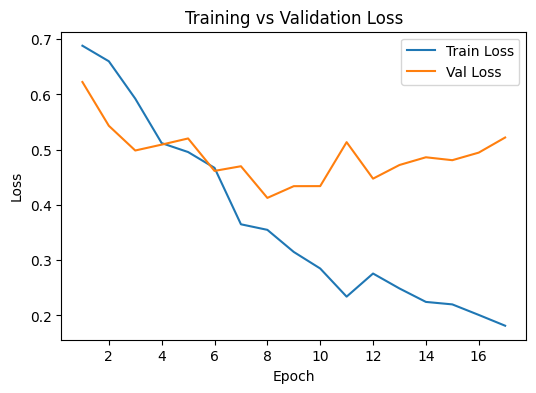

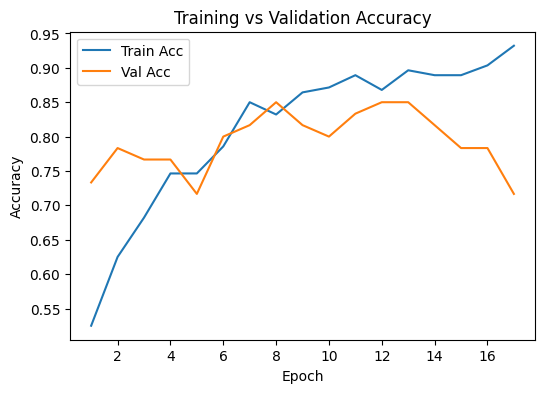

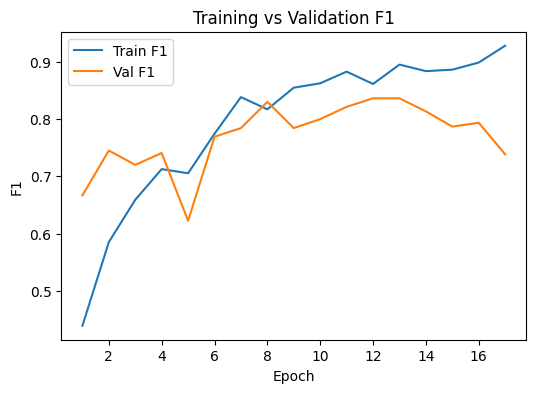

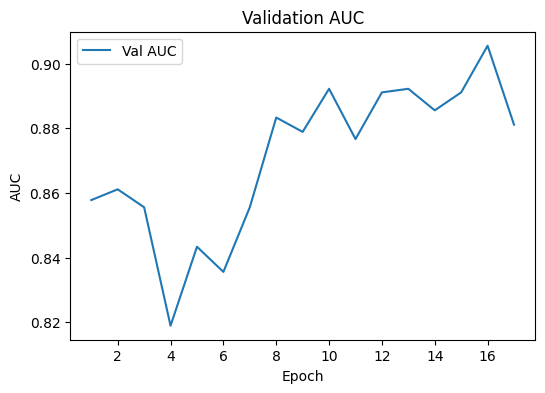

In [ ]:
epochs_range = range(1, len(train_losses) + 1)

plt.figure(figsize=(6, 4))
plt.plot(epochs_range, train_losses, label="Train Loss")
plt.plot(epochs_range, val_losses, label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.show()

plt.figure(figsize=(6, 4))
plt.plot(epochs_range, train_accuracies, label="Train Acc")
plt.plot(epochs_range, val_accuracies, label="Val Acc")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.show()

plt.figure(figsize=(6, 4))
plt.plot(epochs_range, train_f1s, label="Train F1")
plt.plot(epochs_range, val_f1s, label="Val F1")
plt.xlabel("Epoch")
plt.ylabel("F1")
plt.title("Training vs Validation F1")
plt.legend()
plt.show()

plt.figure(figsize=(6, 4))
plt.plot(epochs_range, val_aucs, label="Val AUC")
plt.xlabel("Epoch")
plt.ylabel("AUC")
plt.title("Validation AUC")
plt.legend()
plt.show()

## 14. Test evaluation

In [ ]:
model.load_state_dict(torch.load(best_model_path, map_location=device))
model.eval()

CNN_ViT_BiLSTM(
  (cnn): EfficientNet(
    (conv_stem): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (bn1): BatchNormAct2d(
      32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True
      (drop): Identity()
      (act): SiLU(inplace=True)
    )
    (blocks): Sequential(
      (0): Sequential(
        (0): DepthwiseSeparableConv(
          (conv_dw): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
          (bn1): BatchNormAct2d(
            32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True
            (drop): Identity()
            (act): SiLU(inplace=True)
          )
          (aa): Identity()
          (se): SqueezeExcite(
            (conv_reduce): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
            (act1): SiLU(inplace=True)
            (conv_expand): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
            (gate): Sigmoid()
          )
          (conv_pw): Con

In [ ]:
def test_model(model, loader, device):
    model.eval()

    all_labels = []
    all_preds = []
    all_probs = []

    with torch.no_grad():
        for videos, labels in tqdm(loader, desc="Testing"):
            videos = videos.to(device)
            labels = labels.unsqueeze(1).to(device)

            outputs = model(videos)
            probs = torch.sigmoid(outputs)
            preds = (probs > 0.5).float()

            all_labels.extend(labels.cpu().numpy().ravel())
            all_preds.extend(preds.cpu().numpy().ravel())
            all_probs.extend(probs.cpu().numpy().ravel())

    acc = accuracy_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds)
    auc = roc_auc_score(all_labels, all_probs)

    print(f"Test Accuracy: {acc:.4f}")
    print(f"Test F1-score: {f1:.4f}")
    print(f"Test AUC: {auc:.4f}")

    return np.array(all_labels), np.array(all_preds), np.array(all_probs)

In [ ]:
all_labels, all_preds, all_probs = test_model(model, test_loader, device)

Testing:   0%|          | 0/15 [00:00<?, ?it/s]

Test Accuracy: 0.7500
Test F1-score: 0.7273
Test AUC: 0.8289


## 15. Classification report and confusion matrix

              precision    recall  f1-score   support

        fake       0.71      0.83      0.77        30
        real       0.80      0.67      0.73        30

    accuracy                           0.75        60
   macro avg       0.76      0.75      0.75        60
weighted avg       0.76      0.75      0.75        60

Confusion Matrix:
 [[25  5]
 [10 20]]


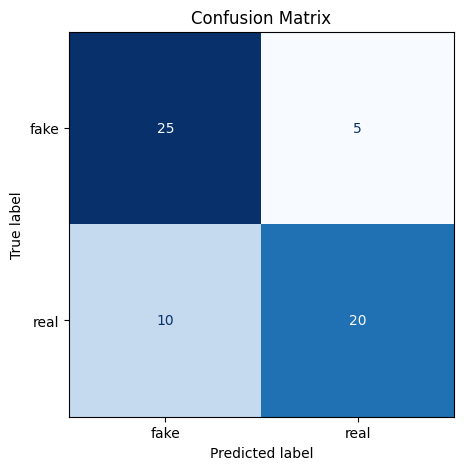

In [ ]:
target_names = ["fake", "real"]

print(classification_report(
    all_labels.astype(int),
    all_preds.astype(int),
    target_names=target_names
))

cm = confusion_matrix(all_labels.astype(int), all_preds.astype(int))
print("Confusion Matrix:\n", cm)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=target_names)
fig, ax = plt.subplots(figsize=(5, 5))
disp.plot(cmap="Blues", colorbar=False, ax=ax)
plt.title("Confusion Matrix")
plt.show()

## 16. Predict one video folder

In [ ]:
def predict_video_folder(model, video_dir, transform, device, num_frames=8):
    model.eval()

    frame_files = sorted([
        os.path.join(video_dir, f)
        for f in os.listdir(video_dir)
        if f.lower().endswith((".jpg", ".jpeg", ".png"))
    ])

    if len(frame_files) == 0:
        raise ValueError(f"No frames found in {video_dir}")

    indices = np.linspace(0, len(frame_files) - 1, num_frames, dtype=int).tolist()

    frames = []
    for i in indices:
        img = Image.open(frame_files[i]).convert("RGB")
        img = transform(img)
        frames.append(img)

    frames = torch.stack(frames, dim=0).unsqueeze(0).to(device)  # (1, T, C, H, W)

    with torch.no_grad():
        output = model(frames)
        prob = torch.sigmoid(output).item()
        pred = 1 if prob > 0.5 else 0

    classes = ["fake", "real"]
    return classes[pred], prob

In [ ]:
sample_video_dir = os.path.join(data_root, "val", "real", "01__talking_angry_couch")
pred_label, prob = predict_video_folder(
    model, sample_video_dir, val_test_transform, device, num_frames=NUM_FRAMES
)
print(f"Prediction: {pred_label} ({prob:.4f})")

Prediction: real (0.9731)


In [4]:
import nbformat

notebook_path = "/content/drive/MyDrive/XST-Deepfake-Detection/new_version/new_version.ipynb"

nb = nbformat.read(notebook_path, as_version=4)

# Remove only widget metadata
if "widgets" in nb.metadata:
    del nb.metadata["widgets"]

nbformat.write(nb, notebook_path)

print("Fixed notebook (outputs preserved ✅)")

Fixed notebook (outputs preserved ✅)
